In [3]:
 !pip install torch torchvision
 !pip install numpy
 !pip install matplotlib
 !pip install scikit-learn
 !pip install tqdm


In [4]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import time
import torchvision
from torchvision.models import resnet18

#Homework Assignment 1: Introduction to PyTorch Tensors

This assignment will help you get familiar with PyTorch tensors, which are the fundamental building blocks of PyTorch for deep learning. You'll practice creating, manipulating, and performing operations on tensors.

###Instructions:
Complete the following tasks using PyTorch. Write your code in Python where you can see `<Your code here>`

###1. Tensor Creation

Create the following tensors:

* A 1D tensor with values from 0 to 9

* A 2x3 tensor filled with zeros

* A 3x3 tensor filled with ones

* A 2x2 identity matrix

* A tensor with random values of shape 4x4

* A tensor from a Python list [3, 7, 2, 9, 1]

In [6]:
#<Your code here>
tensor_1d = torch.tensor([0,1,2,3,4,5,6,7,8,9])
tensor_2x3 = torch.zeros(2, 3)
tensor_3x3 = torch.ones(3, 3)
identity_matrix_2x2 = torch.eye(2)
random_4x4 = torch.rand(4, 4)
from_list = torch.tensor([3, 7, 2, 9, 1])

print("1D tensor (0-9):", tensor_1d)
print("2x3 zeros:\n", tensor_2x3)
print("3x3 ones:\n", tensor_3x3)
print("2x2 identity:\n", identity_matrix_2x2)
print("4x4 random:\n", random_4x4)
print("From list:", from_list)

1D tensor (0-9): tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
2x3 zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
3x3 ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
2x2 identity:
 tensor([[1., 0.],
        [0., 1.]])
4x4 random:
 tensor([[0.7454, 0.5331, 0.6395, 0.0975],
        [0.9408, 0.6926, 0.5949, 0.7907],
        [0.6782, 0.6871, 0.9444, 0.0963],
        [0.3057, 0.1023, 0.7806, 0.4296]])
From list: tensor([3, 7, 2, 9, 1])


###2. Tensor Operations

Given two tensors:

In [7]:
A = torch.tensor([[1, 2], [3, 4]])
B = torch.tensor([[5, 6], [7, 8]])

Perform the following operations:

* Element-wise addition

* Element-wise multiplication

* Matrix multiplication

* Transpose of A

* Sum of all elements in B

* Mean of all elements in A

In [9]:
#<Your code here>
addition = A + B
elementwise_mul = A * B
matrix_mul = torch.mm(A, B)
transpose_A = A.T
sum_B = torch.sum(B)
mean_A = torch.mean(A.float())

print("Element-wise addition:\n", addition)
print("Element-wise multiplication:\n", elementwise_mul)
print("Matrix multiplication:\n", matrix_mul)
print("Transpose of A:\n", transpose_A)
print("Sum of all elements in B:", sum_B)
print("Mean of all elements in A:", mean_A)

Element-wise addition:
 tensor([[ 6,  8],
        [10, 12]])
Element-wise multiplication:
 tensor([[ 5, 12],
        [21, 32]])
Matrix multiplication:
 tensor([[19, 22],
        [43, 50]])
Transpose of A:
 tensor([[1, 3],
        [2, 4]])
Sum of all elements in B: tensor(26)
Mean of all elements in A: tensor(2.5000)


###3. Tensor Indexing and Slicing

Given the tensor:

In [10]:
C = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

* Get the element in the second row, third column

* Get the first row

* Get a sub-tensor of the last two rows and first two columns

* Change the value at position (1, 1) to 10

In [11]:
#<Your code here>
element = C[1, 2]
first_row = C[0]
sub_tensor = C[1:3, 0:2]
C[1, 1] = 10

print("Second row, third column:", element)
print("First row:", first_row)
print("Last two rows, first two columns:\n", sub_tensor)
print("Modified tensor:\n", C)

Second row, third column: tensor(6)
First row: tensor([1, 2, 3])
Last two rows, first two columns:
 tensor([[ 4, 10],
        [ 7,  8]])
Modified tensor:
 tensor([[ 1,  2,  3],
        [ 4, 10,  6],
        [ 7,  8,  9]])


###4. Tensor Reshaping

Given the tensor:

In [12]:
D = torch.arange(12)

* Reshape it to a 3x4 tensor

* Reshape it to a 2x6 tensor (use `view`)

* Flatten it back to a 1D tensor

In [15]:
D_3x4 = D.reshape(3, 4)
D_2x6 = D.view(2, 6)
D_flat = D_2x6.flatten()

print("Original D:", D)
print("Original shape:", D.shape)
print("3x4 tensor:")
print(D_3x4)
print("Shape:", D_3x4.shape)
print("2x6 tensor:")
print(D_2x6)
print("Shape:", D_2x6.shape)
print("Flattened back:")
print(D_flat)
print("Shape:", D_flat.shape)

Original D: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Original shape: torch.Size([12])
3x4 tensor:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Shape: torch.Size([3, 4])
2x6 tensor:
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
Shape: torch.Size([2, 6])
Flattened back:
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape: torch.Size([12])


###5. GPU Operations (Optional - if you have CUDA available)

Given the tensor:

In [16]:
A = torch.tensor([[1, 2], [3, 4]])

* Move tensor A to GPU

* Perform an operation on it while it's on GPU (For example A**2)

* Move it back to CPU

In [18]:
#cuda is not available
A_squared = A ** 2
A_cpu = A_squared.cpu()

print("A squared:\n", A_squared)

A squared:
 tensor([[ 1,  4],
        [ 9, 16]])


###6. Tensor Squeezing and Unsqueezing

Given the tensor:

In [19]:
E = torch.rand(1, 3, 1, 4)

* Use squeeze() to remove all size-1 dimensions

* Use unsqueeze() to add a new dimension at position 1

* Create a 1D tensor of length 5 and unsqueeze it to make it a row vector and a column vector

In [27]:
E_squeezed = torch.squeeze(E)
E_unsqueezed = E_squeezed.unsqueeze(1)
tensor_5 = torch.tensor([1, 2, 3, 4, 5])
row_vector = tensor_5.unsqueeze(0)
col_vector = tensor_5.unsqueeze(1)

print("squeeze() - shape:", E_squeezed.shape)
print("Removed all dimensions with size 1")
print(E_squeezed)
print("After unsqueeze() at position 1 - shape:", E_unsqueezed.shape)
print("1D tensor of length 5:", tensor_5)
print("Shape:", tensor_5.shape)
print("Row vector (1x5):", row_vector)
print("Shape:", row_vector.shape)
print("Column vector (5x1):\n", col_vector)
print("Shape:", col_vector.shape)

squeeze() - shape: torch.Size([3, 4])
Removed all dimensions with size 1
tensor([[0.0067, 0.5593, 0.9492, 0.9329],
        [0.5647, 0.0090, 0.9688, 0.4210],
        [0.7607, 0.2499, 0.3791, 0.8383]])
After unsqueeze() at position 1 - shape: torch.Size([3, 1, 4])
1D tensor of length 5: tensor([1, 2, 3, 4, 5])
Shape: torch.Size([5])
Row vector (1x5): tensor([[1, 2, 3, 4, 5]])
Shape: torch.Size([1, 5])
Column vector (5x1):
 tensor([[1],
        [2],
        [3],
        [4],
        [5]])
Shape: torch.Size([5, 1])


###7. Tensor Type Conversion

Given the tensor:

In [22]:
F = torch.rand(2, 2)

* Convert it to float64 (double precision)

* Convert it to int32 (truncating decimals)

In [30]:
print(F)
F_float64 = F.double()
F_int32 = F.int()

print("Original dtype:", F.dtype)
print("Converted to float64:")
print(F_float64)
print("Dtype:", F_float64.dtype)
print("Converted to int32 (decimals truncated):")
print(F_int32)
print("Dtype:", F_int32.dtype)

tensor([[0.9276, 0.2891],
        [0.8716, 0.7133]])
Original dtype: torch.float32
Converted to float64:
tensor([[0.9276, 0.2891],
        [0.8716, 0.7133]], dtype=torch.float64)
Dtype: torch.float64
Converted to int32 (decimals truncated):
tensor([[0, 0],
        [0, 0]], dtype=torch.int32)
Dtype: torch.int32


###8. Argmax and Argmin Operations

Given the tensor:

In [31]:
G = torch.tensor([[3, 1, 4], [1, 5, 9], [2, 6, 5]])

* Find the index of the maximum value in the entire tensor

* Find the index of the minimum value in each row

* Find the index of the maximum value in each column

In [37]:
print(G)
max_index = torch.argmax(G)
min_per_row = torch.argmin(G, dim=1)
max_per_col = torch.argmax(G, dim=0)

print(f"Index of the maximum value: {max_index}")
print(f"Maximum value: {G.flatten()[max_index]}")
print(f"Index of the minimum value in each row: {min_per_row}")
for i, idx in enumerate(min_per_row):
    print(f"  Row {i}: min at column {idx}, value = {G[i, idx]}")
print(f"Index of the maximum value in each column: {max_per_col}")
for j, idx in enumerate(max_per_col):
    print(f"  Column {j}: max at row {idx}, value = {G[idx, j]}")

tensor([[3, 1, 4],
        [1, 5, 9],
        [2, 6, 5]])
Index of the maximum value: 5
Maximum value: 9
Index of the minimum value in each row: tensor([1, 0, 0])
  Row 0: min at column 1, value = 1
  Row 1: min at column 0, value = 1
  Row 2: min at column 0, value = 2
Index of the maximum value in each column: tensor([0, 2, 1])
  Column 0: max at row 0, value = 3
  Column 1: max at row 2, value = 6
  Column 2: max at row 1, value = 9


###9. Concatenation and Stacking

Given the tensors:

In [38]:
H = torch.tensor([[1, 2], [3, 4]])
I = torch.tensor([[5, 6]])

* Concatenate I below H (vertical concatenation)

* Concatenate a new column of ones to the right of H

* Stack H and I (after making them compatible shapes) along a new dimension (`expand` (for match dimension) and then `stack`)

In [40]:
print(H)
print(I)

vertical_cat = torch.cat([H, I], dim=0)
ones_col = torch.ones(2, 1)
horizontal_cat = torch.cat([H, ones_col], dim=1)
I_expanded = I.expand(2, 2)
stacked = torch.stack([H, I_expanded], dim=0)

print("Concatenate I below H (vertical concatenation):")
print(vertical_cat)
print("Concatenate a new column of ones to the right of H")
print(horizontal_cat)
print("I expanded to shape (2, 2):")
print(I_expanded)
print("Stacked along new dimension (dim=0):")
print(stacked)
print("Shape:", stacked.shape)

tensor([[1, 2],
        [3, 4]])
tensor([[5, 6]])
Concatenate I below H (vertical concatenation):
tensor([[1, 2],
        [3, 4],
        [5, 6]])
Concatenate a new column of ones to the right of H
tensor([[1., 2., 1.],
        [3., 4., 1.]])
I expanded to shape (2, 2):
tensor([[5, 6],
        [5, 6]])
Stacked along new dimension (dim=0):
tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [5, 6]]])
Shape: torch.Size([2, 2, 2])


###10. Autograd Example

* Create a tensor with requires_grad=True (x = 2.0)

* Define a simple function: $y = x^2 + 2x + 1$

* Compute the gradient of y with respect to x at x = 2.0

In [41]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 2*x + 1
print("x =", x)
print("y =", y)

y.backward()

print("gradient of y with respect to x at x = 2.0", x.grad)

x = tensor(2., requires_grad=True)
y = tensor(9., grad_fn=<AddBackward0>)
gradient of y with respect to x at x = 2.0 tensor(6.)


##Homework Assignment 2: PyTorch Fully Connected Neural Network

In this part of the homework, you will need to reproduce the results of the `LinearNet`, which was described in the practical part.  But use `torch.nn.Sequential()` instead of `LinearNet` class with fixed `n_hid_n = 16`.

Start gradually, as it was in the practical part.  **Data generation and preparation**, then **Dividing the data** into test and training samples, then proceed to **Traning Setup** and writing **training** and predict **functions**

In [60]:
import torch.nn as nn
n_hid_n = 16
Net = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(n_hid_n, 1)
)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(Net.parameters(), lr=0.01)

In [61]:
x = torch.linspace(0, 10, 100).reshape(-1, 1)
true_slope = 2.0
true_intercept = 3.0
noise = torch.randn(x.size()) * 1.5
y = true_slope * x + true_intercept + noise
x_np = x.numpy()
y_np = y.numpy()
x_train, x_test, y_train, y_test = train_test_split(x_np, y_np, test_size=0.2, random_state=42)

x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)
x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

  0%|          | 0/500 [00:00<?, ?it/s]

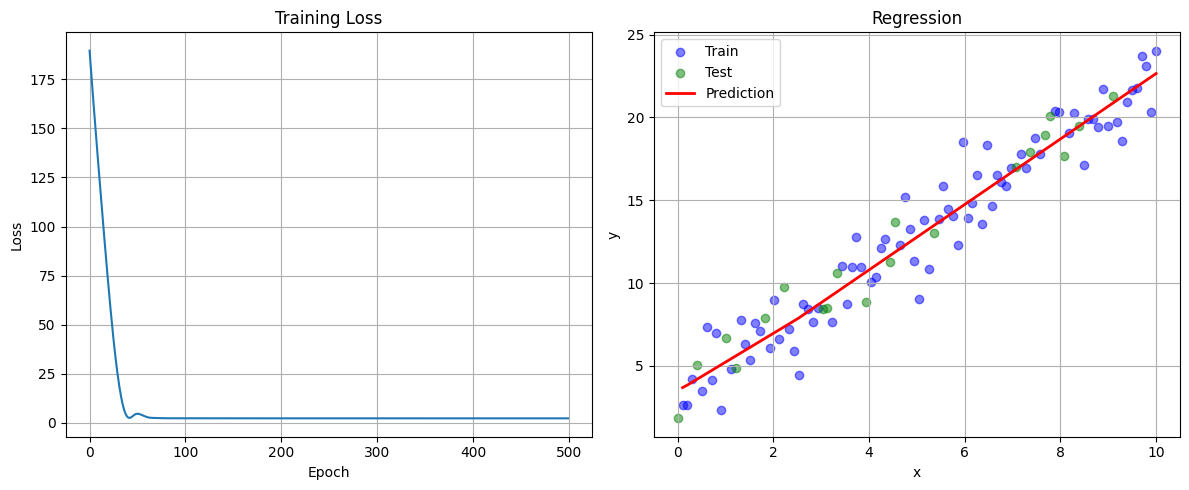

In [62]:
def train_model(model, x_train, y_train, criterion, optimizer, num_epochs=500):
    model.train()
    losses = []

    for epoch in tqdm(range(num_epochs)):
        pred = model(x_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return model, losses

trained_model, losses = train_model(Net, x_train, y_train, criterion, optimizer, num_epochs=500)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x_train, y_train, alpha=0.5, color='blue', label='Train')
plt.scatter(x_test, y_test, alpha=0.5, color='green', label='Test')

with torch.no_grad():
    x_sorted = torch.sort(x_train[:, 0])[0].reshape(-1, 1)
    y_pred = trained_model(x_sorted)
    plt.plot(x_sorted, y_pred, 'r-', linewidth=2, label='Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Homework Assignment 3: PyTorch Convolutional Neural Network (CNN)

Build and train a simple convolutional neural network (CNN) for image classification of MNIST dataset.

###1. Basic CNN Implementation
Implement this architecture:

* Conv Layer 1: 1 input channels, 16 output channels, 3x3 kernel, padding 1

* ReLU activation

* Max Pooling: 2x2

* Conv Layer 2: 16 input channels, 32 output channels, 3x3 kernel, padding 1

* ReLU activation

* Max Pooling: 2x2

* Flatten

* Fully Connected Layer: 32 * 7 * 7 → 128

* ReLU activation

* Output Layer: 128 → 10 (for MNIST)

In [64]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = nn.ReLU()(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = nn.ReLU()(x)
        x = self.pool(x)
        x = x.view(-1, 32 * 7 * 7)
        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        return x

model = SimpleCNN()

###2. Dataset Preparation

Load and prepare MNIST dataset:

In [66]:
# TODO: Create proper transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Adjust for MNIST
])

# TODO: Load dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# TODO: Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.83MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


###3. Training Loop

Complete the training loop:

In [67]:
import torch.optim as optim

#<Your code here>
criterion = nn.CrossEntropyLoss()  # TODO: Choose proper loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)  # TODO: Choose optimizer

In [70]:
from tqdm.auto import tqdm

def train_cnn(model, train_loader, criterion, optimizer, num_epochs):
    '''
    Trains a CNN model using mini-batch gradient descent.

    Args:
        model (torch.nn.Module): CNN model to train
        train_loader (torch.utils.data.DataLoader): DataLoader for training data
        criterion: Loss function (e.g., CrossEntropyLoss)
        optimizer: Optimizer (e.g., SGD, Adam)
        num_epochs (int): Number of training epochs
        print_interval (int): Print loss every N batches

    Returns:
        tuple: (trained_model, list_of_training_losses)
    '''
    model.train()  # Set model to training mode
    train_losses = []
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0.0
        batch_count = 0
        for batch_idx, (images, labels) in enumerate(train_loader):
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            batch_count += 1

        # Store epoch statistics
        avg_epoch_loss = epoch_loss / batch_count
        train_losses.append(avg_epoch_loss)
        print(f'Epoch {epoch+1} completed. Average Loss: {avg_epoch_loss:.4f}')

    return model, train_losses

In [71]:
train_cnn_model, train_losses_cnn = train_cnn(model, train_loader, criterion, optimizer, num_epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 completed. Average Loss: 0.2046
Epoch 2 completed. Average Loss: 0.0566
Epoch 3 completed. Average Loss: 0.0395
Epoch 4 completed. Average Loss: 0.0289
Epoch 5 completed. Average Loss: 0.0230


In [79]:
def test_cnn(model, test_loader):
    """
    Evaluates a model's accuracy on a test dataset.

    Args:
        model (torch.nn.Module): Trained model to evaluate
        test_loader (torch.utils.data.DataLoader): DataLoader for test data
    """
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Get predicted class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

In [80]:
test_cnn(train_cnn_model, test_loader)

Test Accuracy: 98.93%
